Goal:
Build a physics-based simulation of two-body orbital dynamics using numerical methods (RK4), with visualization and validation of conservation laws.

Core Components:

    State Representation

    Position: r = [x, y]

    Velocity: v = [vx, vy]

    Combined state: [x, y, vx, vy]

    Physics Model

    Gravitational acceleration:
    a = -μ * r / |r|^3

    μ = G * M (gravitational parameter)

    Numerical Integration

    Implement Runge-Kutta 4 (RK4)

    Define derivatives function:

        dx/dt = vx

        dy/dt = vy

        dv/dt = acceleration

    Simulation Loop

    Initialize state

    Step forward using RK4

    Store trajectory over time

    Visualization

    Use matplotlib

    Plot orbit (x vs y)

    Mark central body at origin

    Ensure equal axis scaling

    Validation (Important)

    Check conservation of:

        Energy: E = (1/2)v^2 - μ/r

        Angular momentum: L = r × v

    Plot over time to verify stability

    Test Cases

    Circular orbit (v = sqrt(μ/r))

    Elliptical orbit (slightly lower velocity)

    Escape trajectory (v > escape velocity)

    Optional Extensions

    N-body simulation

    Hohmann transfer

    Compare integrators (RK4 vs Verlet)

    Add animation or interactivity

Tech Stack:

    Python

    NumPy

    matplotlib

Key Outcome:
A modular, physics-based simulation demonstrating numerical integration, orbital dynamics, and conservation laws—ready for GitHub and resume inclusion. 

Goal:
Build an interactive Python notebook that not only simulates orbital motion, but analyzes numerical methods (Euler, RK4, Verlet) and demonstrates stability, accuracy, and failure modes.

Core Idea:
Not just “plot an orbit” — treat this like a small engineering experiment:

    implement physics

    compare integrators

    validate results (energy, momentum)

    analyze where things break

Structure:

    Introduction

    Brief explanation of orbital motion and why numerical methods are needed

    Physics Setup

    Define state (position + velocity)

    Implement gravitational acceleration

    Integrators

    Implement Euler, RK4, and Verlet separately

    Simulation

    Run all methods with identical initial conditions

    Visualization

    Plot orbits for each method on same graph

    Analysis (Most Important)

    Plot energy over time (look for drift)

    Plot angular momentum

    Compare stability across methods

    Failure Modes

    Increase timestep and show instability

    Demonstrate why Euler fails

    Conclusion

    Summarize tradeoffs (accuracy vs stability vs simplicity)

Tech Stack:

    Python

    NumPy

    matplotlib

    Jupyter Notebook

Optional:

    ipywidgets for sliders (dt, velocity, etc.)

Key Differentiator:
Focus on numerical analysis and validation, not just visualization. Show understanding of:

    error growth

    conservation laws

    integrator tradeoffs

Outcome:
A notebook that reads like a mini technical report + simulation lab, suitable for GitHub and resume use.

### In this notebook, I'm going to simulate two body orbital mechanics using a variety of numerical integrators to essentially solve Newton's Law of Gravitation. To this end, I need the following three packages.

In [21]:
import numpy as np #For arrays and vector math
import scipy as sp
import matplotlib.pyplot as plt #For visualization
from matplotlib.animation import FuncAnimation

In order to simulate orbital mechanics, we need to track position, velocity, and mass. We also need to define our gravitational constant. For now, and for the sake of not letting the numbers get to big, we'll call G = 1. We are going to make a class for an orbiting body with the stated variables. The position and velocity are vectors, so we use np.array([x,y,z]) for those. We're going to assert that position and velocity are 3D vectors, just to be safe.

In [37]:
gravitational_constant = 1.0

class OrbitingBody:
    def __init__(self, name:str, position, velocity, mass = 1.0):
        self.name = name
        self.position = np.asarray(position, dtype = float)
        assert self.position.shape == (3,)
        self.velocity = np.asarray(velocity, dtype = float)
        assert self.velocity.shape == (3,)
        self.mass = mass

    def __str__(self):
        result = f"{self.name} - Position: {self.position} - Velocity: {self.velocity}"
        return result


Note that right now our OrbitingBody doesn't have any clue about gravity or the forces acting upon it. This is where the bulk of the numerical integration story start. We want to start with Euler, since it's the simplest to implement, but we will show that it has it's problems. THIS IS WHERE WE EXPLAIN THE BASIC MATH

In [44]:
def euler_comp_acc(bodies, G):
    accs = []

    for i, body in enumerate(bodies):
        acc = np.zeros(3)

        for j, other in enumerate(bodies):
            if i == j:
                continue

            r_vec = other.position - body.position
            dist = np.linalg.norm(r_vec)
            if dist == 0:
                print("Collision")
                continue

            acc += G * other.mass * r_vec / dist**3
    

        accs.append(acc)
    
    return accs

def euler_apply_acc(bodies, G, dt = 0.01):
    accs = euler_comp_acc(bodies, G)

    for body, acc in zip(bodies, accs):
        body.velocity += acc * dt
        body.position += body.velocity * dt

And then we apply. we'll set up two orbiting bodies, then run the simulation, displaying the results

In [ ]:
planet = OrbitingBody(
    "Planet",
    position=np.array([0.0, 0.0, 0.0]),
    velocity=np.array([0.0, 0.0, 0.0]),
    mass=1000.0
)

satellite = OrbitingBody(
    "Moon",
    position=np.array([10.0, 0.0, 0.0]),
    velocity=np.array([0.0, 10.0, 1.0]),
    mass=1.0
)

bodies = [planet, satellite]

print(planet)
print(satellite)

for _ in range(2000):
    euler_apply_acc(bodies, G = 1.0, dt = 0.01)
    print(planet)
    print(satellite)



#But numbers don't really make sense, or look good. let's graph it

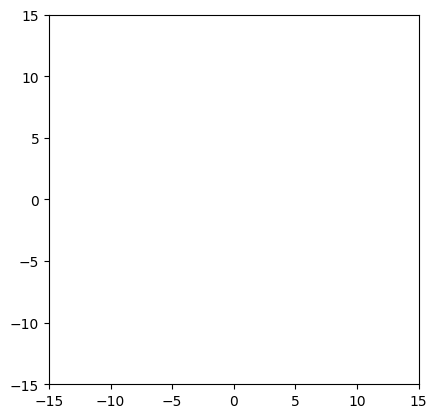